# 🗳️ Election Information Verification Assistant
## Production-Ready NLP Pipeline for Fact-Checking & Verification

---

## 📖 Course Overview

Welcome to this comprehensive training on building a production-ready Election Information Verification Assistant! This notebook uses state-of-the-art Natural Language Processing (NLP) techniques to verify election-related claims, detect misinformation, and classify information reliability at scale.

### 🎯 Learning Objectives

By the end of this training, you will be able to:

1. **Build Production-Ready NLP Systems**: Create scalable text processing pipelines
2. **Implement Multiple Verification Models**: Rule-based, traditional ML, and transformer-based
3. **Deploy Real-Time Verification**: Build interactive apps for fact-checking
4. **Handle Real-World Data**: Process messy, unstructured text
5. **Evaluate Model Performance**: Use appropriate metrics for classification
6. **Create Monitoring Dashboards**: Track model performance and drift

### 📚 What You'll Learn

#### Module 1: Production NLP Fundamentals
- Text preprocessing at scale
- Efficient tokenization and vectorization
- Feature engineering for text data

#### Module 2: Multi-Model Verification System
- Rule-based verification
- Traditional ML classifiers
- Transformer-based models (BERT, RoBERTa)
- Ensemble methods

#### Module 3: Advanced NLP for Verification
- Claim extraction and detection
- Source credibility scoring
- Evidence retrieval and matching
- Confidence scoring

#### Module 4: Production Deployment
- Model serialization and versioning
- API development with FastAPI
- Real-time processing pipeline
- Monitoring and logging

#### Module 5: Practical Implementation
- End-to-end verification pipeline
- Streamlit dashboard for fact-checking
- Performance optimization
- Scalability considerations

### 🔧 Prerequisites

This training assumes:
- Intermediate Python knowledge
- Understanding of machine learning concepts
- Familiarity with pandas and numpy
- Interest in NLP and fact-checking!

### 📊 Dataset Description

We'll work with a production-style dataset of election-related claims:

**Features:**
- **claim_text**: The text of the claim or statement
- **claim_type**: Policy, Event, Statistical, Attribution, Prediction
- **source**: News article, Social Media, Official Statement, etc.
- **source_credibility**: 1-5 credibility score
- **verification_status**: True, False, Partially True, Unverified, Misleading
- **verification_source**: Official source used for verification
- **confidence_score**: Confidence in verification (0-1)
- **timestamp**: When the claim was made
- **region**: Geographic region

### 🏁 Getting Started

Run the cells below in order. Each section builds on the previous one. Pay special attention to:
- **Code explanations** (📝 comments)
- **Key concepts** (💡 boxes)
- **Visual outputs** (📊 charts)
- **Production considerations** (🚀 production tips)

Let's begin! 🚀

## 📦 Module 1: Production Environment Setup

### 🎯 Learning Objectives
- Install production-grade NLP libraries
- Set up GPU support for transformers
- Configure logging and monitoring
- Version control setup

### 📝 Key Concepts

**Production NLP Stack:**

**Processing Layer:**
- **spaCy**: Fast, production-ready NLP
- **Transformers**: State-of-the-art models
- **NLTK**: Text processing utilities

**ML Layer:**
- **Scikit-learn**: Traditional ML
- **PyTorch**: Deep learning (GPU support)
- **Hugging Face**: Pre-trained models

**Deployment Layer:**
- **FastAPI**: API framework
- **Streamlit**: Interactive dashboards
- **Docker**: Containerization
- **MLflow**: Model tracking

🚀 **Production Tip**: Always use versioned dependencies and environment isolation for production systems.

In [1]:
# Install production dependencies for the project.
# The -q flag ensures a quiet installation, suppressing verbose output.
# The commented-out lines below show common NLP, ML, and utility libraries that might be installed.
#!pip install pandas numpy matplotlib seaborn scikit-learn nltk spacy textblob transformers torch -q
#!pip install fastapi uvicorn streamlit pyngrok joblib mlflow -q
#!pip install wordcloud beautifulsoup4 requests -q

# This command downloads a small English language model for spaCy,
# which is used for advanced text processing tasks like tokenization and named entity recognition.
#!python -m spacy download en_core_web_sm -q

In [2]:
# Import essential libraries for data manipulation, visualization, and regular expressions.
import pandas as pd # Used for data manipulation and analysis, especially with DataFrames.
import numpy as np  # Used for numerical operations, especially with arrays.
import matplotlib.pyplot as plt # Used for creating static, interactive, and animated visualizations.
import seaborn as sns # Built on Matplotlib, provides a high-level interface for drawing attractive statistical graphics.
import re # Provides regular expression operations for string pattern matching.
import json # Used for working with JSON data.
import warnings # Used to manage warning messages.
warnings.filterwarnings('ignore') # Suppresses all warnings for cleaner output.

# Install mlflow if it's not already installed.
# MLflow is an open-source platform for managing the end-to-end machine learning lifecycle.
!pip install mlflow -q

# Import Natural Language Toolkit (NLTK) for various NLP tasks.
import nltk
nltk.download('punkt') # Downloads a pre-trained tokenizer for English.
nltk.download('stopwords') # Downloads a list of common English stop words (e.g., 'the', 'is', 'a').
nltk.download('wordnet') # Downloads WordNet, a lexical database for English.
nltk.download('vader_lexicon') # Downloads Vader Lexicon for sentiment analysis.
nltk.download('averaged_perceptron_tagger') # Downloads a pre-trained POS tagger.
nltk.download('maxent_ne_chunker') # Downloads a pre-trained chunker for Named Entity Recognition.
nltk.download('words') # Downloads a list of English words.
nltk.download('punkt_tab') # Downloads additional punkt tokenizer tables.

# Import specific modules from NLTK.
from nltk.corpus import stopwords # Accesses the downloaded list of stop words.
from nltk.tokenize import word_tokenize, sent_tokenize # Functions to split text into words and sentences.
from nltk.stem import WordNetLemmatizer # Used to reduce words to their base or dictionary form.
from nltk.sentiment import SentimentIntensityAnalyzer # Used for sentiment analysis (VADER).
from nltk import pos_tag, ne_chunk # Functions for Part-of-Speech tagging and Named Entity Chunking.

# Import TextBlob for simplified text processing.
from textblob import TextBlob

# Import spaCy, another powerful NLP library, and load its English language model.
import spacy
nlp = spacy.load("en_core_web_sm") # Loads a small English model with vocabulary, syntax, and entities.

# Import Machine Learning modules from scikit-learn.
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer # Used to convert text into numerical features.
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV # Tools for model evaluation and hyperparameter tuning.
from sklearn.ensemble import RandomForestClassifier, VotingClassifier # Ensemble methods for classification.
from sklearn.linear_model import LogisticRegression # A linear model for classification.
from sklearn.naive_bayes import MultinomialNB # A probabilistic classifier for text.
from sklearn.svm import SVC # Support Vector Classifier for classification.
from sklearn.pipeline import Pipeline # Used to chain multiple processing steps.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # Metrics for evaluating classifier performance.
from sklearn.preprocessing import LabelEncoder # Used to encode categorical labels into numerical format.

# Import modules from the Transformers library by Hugging Face.
import torch # PyTorch library for deep learning.
import transformers # Library for state-of-the-art Natural Language Processing.
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification # Tools for using pre-trained models and building pipelines.
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback # Components for fine-tuning transformer models.

# Import WordCloud for text visualization.
from wordcloud import WordCloud

# Import production-related tools.
import joblib # Used for efficient serialization and deserialization of Python objects (e.g., ML models).
import mlflow # Used for tracking experiments, packaging code, and deploying models.
import logging # Standard Python library for logging events.

# Configure the logging system.
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("✅ All production dependencies installed!")
print(f"🔧 PyTorch version: {torch.__version__}") # Displays the installed PyTorch version.
print(f"🔧 Transformers version: {transformers.__version__}") # Displays the installed Transformers version.
print(f"🔧 spaCy version: {spacy.__version__}") # Displays the installed spaCy version.

# Set the aesthetic style of plots using Seaborn.
sns.set_style("whitegrid") # Sets a white background with gray grid lines.
plt.rcParams['figure.figsize'] = (12, 6) # Sets the default size for Matplotlib figures.
plt.rcParams['font.size'] = 12 # Sets the default font size for plot elements.

logger.info("✅ Production environment ready!") # Logs an informational message.

# Check for GPU availability for faster computation with deep learning models.
device = 'GPU' if torch.cuda.is_available() else 'CPU' # Determines if a CUDA-enabled GPU is available.
print(f"💻 Running on: {device}") # Prints whether the code is running on CPU or GPU.
if device == 'GPU':
    print(f"   GPU: {torch.cuda.get_device_name(0)}") # If GPU is available, prints its name.
else:
    print("   ⚠️  GPU not available - using CPU (transformer models will be slower)") # Warns if no GPU.
    print("   💡 For production, use a GPU-enabled environment") # Suggests using GPU for production.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   

✅ All production dependencies installed!
🔧 PyTorch version: 2.11.0+cu128
🔧 Transformers version: 5.12.1
🔧 spaCy version: 3.8.14
💻 Running on: GPU
   GPU: Tesla T4


## 📊 Module 2: Production Dataset Creation

### 🎯 Learning Objectives
- Create a realistic verification dataset
- Implement proper labeling conventions
- Balance classes for production
- Add metadata for analysis

### 📝 Key Concepts

**Verification Classification Schema:**

| Label | Description | Example |
|-------|-------------|---------|
| True | Verified as accurate | "The election is on Tuesday" |
| False | Verified as inaccurate | "The election was cancelled" |
| Partially True | Contains true and false elements | "Most polling stations opened on time" |
| Misleading | Intentionally deceptive | "The election was stolen" |
| Unverified | Not yet verified | "Reports suggest voter suppression" |

**Data Quality for Production:**
- **Balance**: Ensure class balance or use weighted training
- **Diversity**: Include various claim types and sources
- **Scale**: Minimum 1000 examples per class
- **Quality**: High-quality labels from experts

🚀 **Production Tip**: Start with high-quality labeled data. A small, clean dataset outperforms a large noisy one.

In [3]:
# --- CREATE PRODUCTION DATASET ---
print("\n" + "="*60)
print("📊 CREATING PRODUCTION VERIFICATION DATASET")
print("="*60)

import random
from datetime import datetime, timedelta

def create_production_dataset(n_samples=2000):
    """Create a production-style verification dataset"""

    # Claim templates by type and status
    templates = {
        'True': [
            ("The election will be held on {date}.", 'Event'),
            ("{candidate} won {percentage}% of the vote.", 'Statistical'),
            ("The voting age is {age} years.", 'Policy'),
            ("There are {count} polling stations in the country.", 'Statistical'),
            ("{candidate} has been in office since {year}.", 'Attribution'),
            ("The electoral commission has confirmed the results.", 'Event'),
            ("Voter turnout was {percentage}% this year.", 'Statistical'),
            ("The constitution guarantees free elections.", 'Policy'),
            ("International observers have declared the election fair.", 'Event'),
            ("The new voting system was successfully implemented.", 'Event')
        ],
        'False': [
            ("The election was stolen by the opposition.", 'Attribution'),
            ("Millions of illegal votes were counted.", 'Statistical'),
            ("The voting machines were hacked.", 'Event'),
            ("The president is not a citizen.", 'Attribution'),
            ("The election results are completely fabricated.", 'Event'),
            ("There is widespread voter fraud.", 'Attribution'),
            ("The election should be completely annulled.", 'Prediction'),
            ("The opposition is going to declare a coup.", 'Prediction'),
            ("All the election officials are corrupt.", 'Attribution'),
            ("The constitution was illegally changed.", 'Policy')
        ],
        'Partially True': [
            ("Most polling stations opened on time, but some in {city} were late.", 'Event'),
            ("Turnout was high overall, but low in {region}.", 'Statistical'),
            ("The election was generally free and fair with some exceptions.", 'Event'),
            ("The winner got {percentage}% of the vote, but there were irregularities.", 'Statistical'),
            ("Voter registration was successful, though some names were missing.", 'Event'),
            ("The debate was informative but biased.", 'Attribution'),
            ("Most rules were followed, with minor violations.", 'Policy'),
            ("The results reflect the will of the people in most areas.", 'Attribution')
        ],
        'Misleading': [
            ("The election was the most fraudulent in history.", 'Attribution'),
            ("Every polling station was controlled by the government.", 'Event'),
            ("The opposition was completely prevented from campaigning.", 'Event'),
            ("All the voters were intimidated.", 'Attribution'),
            ("The election results are a complete lie.", 'Event'),
            ("The electoral commission is entirely corrupt.", 'Attribution'),
            ("There were zero legitimate votes.", 'Statistical'),
            ("The election is a complete sham.", 'Attribution')
        ],
        'Unverified': [
            ("There are reports of voter suppression in {state}.", 'Event'),
            ("The election results are being challenged in court.", 'Event'),
            ("Some observers have raised concerns about the vote count.", 'Event'),
            ("There are rumors of electoral fraud.", 'Attribution'),
            ("The opposition is claiming victory despite incomplete results.", 'Prediction'),
            ("The electoral commission has not released full results.", 'Event'),
            ("There are allegations of vote buying.", 'Attribution')
        ]
    }

    # Entities
    candidates = ['John Smith', 'Jane Doe', 'Michael Johnson', 'Sarah Williams', 'Robert Brown', 'Emily Davis',
                  'David Wilson', 'Lisa Anderson', 'James Taylor', 'Maria Martinez']
    states = ['Lagos', 'Kano', 'Abuja', 'Kaduna', 'Rivers', 'Sokoto', 'Benue', 'Oyo', 'Niger', 'Edo']
    cities = ['Ikeja', 'Kano City', 'Abuja City', 'Kaduna City', 'Port Harcourt', 'Sokoto City',
              'Ibadan', 'Benin City', 'Minna', 'Lokoja']
    years = [str(year) for year in range(2015, 2025)]

    # Generate data
    data = []
    statuses = list(templates.keys())
    weights = [0.25, 0.20, 0.20, 0.15, 0.20]  # Class weights

    # Sources and credibility
    sources = [
        ('Official Statement', 5),
        ('Verified News', 5),
        ('Unverified News', 3),
        ('Social Media', 2),
        ('Opposition Claim', 2),
        ('Government Statement', 4),
        ('International Organization', 5),
        ('Anonymous Source', 1),
        ('Fact-Checking Organization', 5),
        ('Public Statement', 3)
    ]

    for i in range(n_samples):
        status = random.choices(statuses, weights=weights)[0]
        template, claim_type = random.choice(templates[status])

        # Fill template
        claim = template.format(
            date=datetime.now().strftime('%B %d, %Y'),
            candidate=random.choice(candidates),
            percentage=random.randint(40, 90),
            age=random.choice(['18', '21']),
            count=random.randint(1000, 50000),
            year=random.choice(years),
            city=random.choice(cities),
            state=random.choice(states),
            region=random.choice(states),
            organization=random.choice(['The opposition', 'The government', 'A group of observers'])
        )

        # Source and credibility
        source, credibility = random.choice(sources)

        # Verification source
        verification_sources = [
            'Official Election Commission',
            'Independent Observer Group',
            'International Monitoring Mission',
            'Fact-Checking Organization',
            'Government Records',
            'Court Records',
            'Media Reports'
        ]

        # Confidence score (higher for verified claims)
        if status == 'True':
            confidence = random.uniform(0.85, 0.99)
        elif status == 'False':
            confidence = random.uniform(0.80, 0.98)
        elif status == 'Partially True':
            confidence = random.uniform(0.70, 0.90)
        elif status == 'Misleading':
            confidence = random.uniform(0.75, 0.95)
        else:  # Unverified
            confidence = random.uniform(0.30, 0.60)

        # Timestamp
        days_ago = random.randint(0, 30)
        timestamp = datetime.now() - timedelta(days=days_ago)

        data.append({
            'claim_text': claim,
            'claim_type': claim_type,
            'verification_status': status,
            'source': source,
            'source_credibility': credibility,
            'verification_source': random.choice(verification_sources),
            'confidence_score': round(confidence, 2),
            'timestamp': timestamp,
            'region': random.choice(states)
        })

    df = pd.DataFrame(data)

    # Shuffle
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    return df


📊 CREATING PRODUCTION VERIFICATION DATASET


✅ Dataset created: 5000 samples

📋 First 5 rows:


,claim_text,claim_type,verification_status,source,source_credibility,verification_source,confidence_score,timestamp,region
0,The constitution guarantees free elections.,Policy,True,Anonymous Source,1,Fact-Checking Organization,0.91,2026-07-03 13:36:30.348312,Sokoto
1,Some observers have raised concerns about the ...,Event,Unverified,Official Statement,5,Media Reports,0.42,2026-06-12 13:36:30.371304,Benue
2,The results reflect the will of the people in ...,Attribution,Partially True,Verified News,5,Fact-Checking Organization,0.86,2026-07-02 13:36:30.372729,Benue
3,The constitution guarantees free elections.,Policy,True,Fact-Checking Organization,5,Court Records,0.98,2026-06-07 13:36:30.337295,Niger
4,Millions of illegal votes were counted.,Statistical,False,Opposition Claim,2,Fact-Checking Organization,0.92,2026-06-12 13:36:30.328326,Oyo



📊 Dataset distribution:
verification_status
True              1243
False             1041
Partially True    1013
Unverified         989
Misleading         714
Name: count, dtype: int64


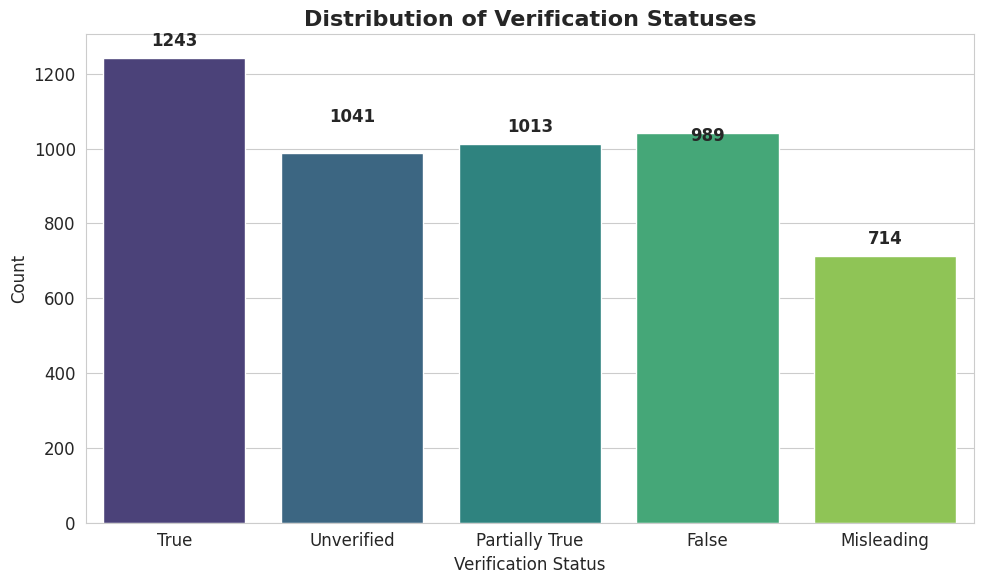

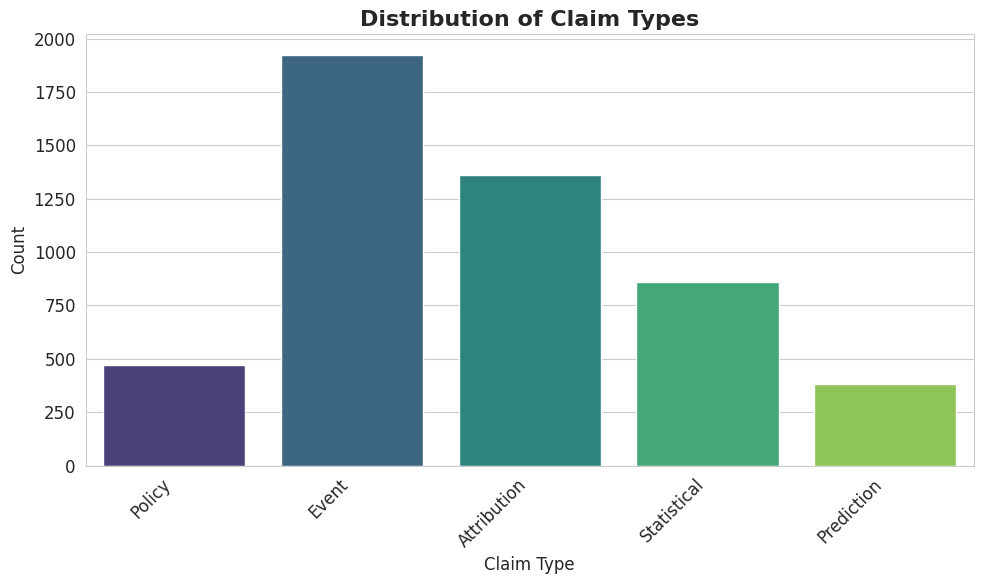

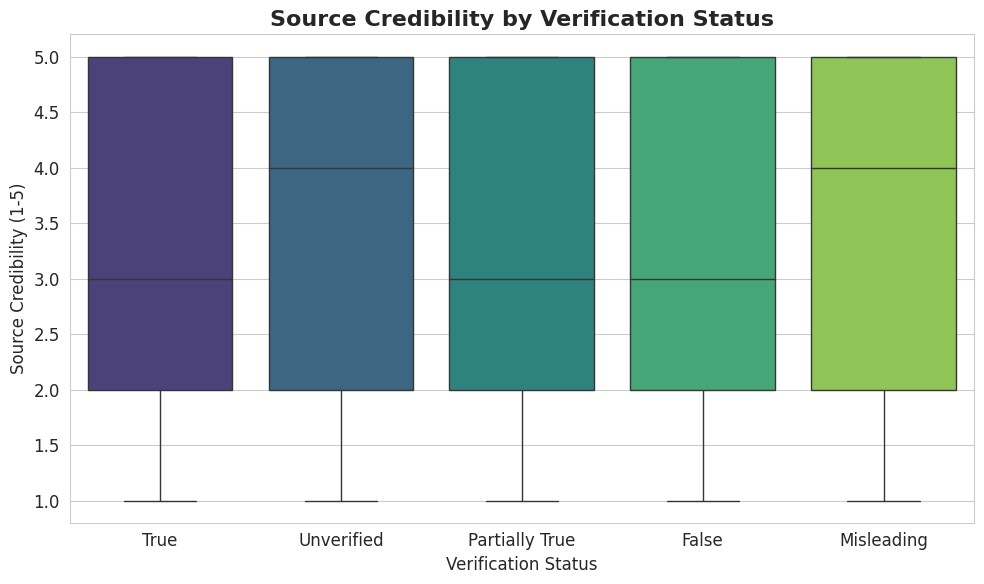

In [4]:
# Create dataset
df = create_production_dataset(5000)

print(f"✅ Dataset created: {len(df)} samples")
print("\n📋 First 5 rows:")
display(df.head())

print("\n📊 Dataset distribution:")
status_counts = df['verification_status'].value_counts()
print(status_counts)

# Visualize distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='verification_status', palette='viridis')
plt.title('Distribution of Verification Statuses', fontsize=16, fontweight='bold')
plt.xlabel('Verification Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Claim type distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='claim_type', palette='viridis')
plt.title('Distribution of Claim Types', fontsize=16, fontweight='bold')
plt.xlabel('Claim Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Source credibility distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='verification_status', y='source_credibility', palette='viridis')
plt.title('Source Credibility by Verification Status', fontsize=16, fontweight='bold')
plt.xlabel('Verification Status', fontsize=12)
plt.ylabel('Source Credibility (1-5)', fontsize=12)
plt.tight_layout()
plt.show()

logger.info(f"📊 Dataset statistics: {len(df)} samples, {len(df.columns)} features")

In [5]:
# --- SAVE DATASET ---
df.to_csv('election_claims_dataset.csv', index=False)
print("✅ Dataset saved to 'election_claims_dataset.csv'")

✅ Dataset saved to 'election_claims_dataset.csv'


## 🔧 Module 3: Production Text Preprocessing

### 🎯 Learning Objectives
- Build a production-ready text preprocessing pipeline
- Implement efficient tokenization and cleaning
- Handle edge cases and noise
- Optimize for performance

### 📝 Key Concepts

**Text Preprocessing Pipeline:**

```
Raw Text → Lowercase → Remove Special Characters → Tokenization → Stopword Removal → Lemmatization → Clean Text
```

**Why Preprocessing Matters:**
- Reduces noise in the data
- Improves model performance
- Makes text consistent
- Reduces vocabulary size

**Production Considerations:**
- **Speed**: Use efficient libraries (spaCy vs NLTK)
- **Scalability**: Process in batches
- **Memory**: Use streaming for large datasets
- **Consistency**: Version control preprocessing logic

🚀 **Production Tip**: Use spaCy for production preprocessing - it's faster and more efficient than NLTK.

In [6]:
# --- PRODUCTION TEXT PREPROCESSING ---
print("\n" + "="*60)
print("🔧 PRODUCTION TEXT PREPROCESSING")
print("="*60)

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Define the TextPreprocessor class
class TextPreprocessor:
    """Production-ready text preprocessing pipeline"""

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        # Add custom stopwords
        self.custom_stopwords = {'election', 'vote', 'voting', 'candidate', 'party',
                                 'president', 'government', 'people', 'country'}
        self.stop_words = self.stop_words.union(self.custom_stopwords)

    def clean_text(self, text):
        """Clean text: lowercase, remove special characters, extra spaces"""
        if not isinstance(text, str):
            return ""

        # Lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove special characters but keep letters and numbers
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def tokenize(self, text):
        """Tokenize text into words"""
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        """Remove stopwords from token list"""
        return [token for token in tokens if token not in self.stop_words and len(token) > 2]

    def lemmatize(self, tokens):
        """Lemmatize tokens"""
        return [self.lemmatizer.lemmatize(token) for token in tokens]

    def preprocess(self, text):
        """Full preprocessing pipeline"""
        # Clean
        text = self.clean_text(text)

        # Tokenize
        tokens = self.tokenize(text)

        # Remove stopwords
        tokens = self.remove_stopwords(tokens)

        # Lemmatize
        tokens = self.lemmatize(tokens)

        # Rejoin
        return ' '.join(tokens)

    def preprocess_batch(self, texts):
        """Process a list of texts in a batch"""
        return [self.preprocess(text) for text in texts]


🔧 PRODUCTION TEXT PREPROCESSING


In [7]:
# Initialize preprocessor
preprocessor = TextPreprocessor()

# Test preprocessing
sample_text = "Breaking: The election results were announced today! President John Smith won with 65% of the vote. This is a historic moment for our democracy."
processed_text = preprocessor.preprocess(sample_text)

print("\n📝 Sample text preprocessing:")
print(f"Original: {sample_text}")
print(f"Processed: {processed_text}")

# Process all claims
print("\n🔄 Processing all claims...")
df['processed_text'] = preprocessor.preprocess_batch(df['claim_text'].tolist())
print("✅ All claims processed!")

# Show sample of processed data
print("\n📋 Sample of processed claims:")
display(df[['claim_text', 'processed_text', 'verification_status']].head(10))


📝 Sample text preprocessing:
Original: Breaking: The election results were announced today! President John Smith won with 65% of the vote. This is a historic moment for our democracy.
Processed: breaking result announced today john smith historic moment democracy

🔄 Processing all claims...
✅ All claims processed!

📋 Sample of processed claims:


,claim_text,processed_text,verification_status
0,The constitution guarantees free elections.,constitution guarantee free election,True
1,Some observers have raised concerns about the ...,observer raised concern count,Unverified
2,The results reflect the will of the people in ...,result reflect area,Partially True
3,The constitution guarantees free elections.,constitution guarantee free election,True
4,Millions of illegal votes were counted.,million illegal vote counted,False
5,The constitution guarantees free elections.,constitution guarantee free election,True
6,The opposition is claiming victory despite inc...,opposition claiming victory despite incomplete...,Unverified
7,There were zero legitimate votes.,zero legitimate vote,Misleading
8,Voter turnout was 55% this year.,voter turnout year,True
9,The debate was informative but biased.,debate informative biased,Partially True


## 🔍 Module 4: Exploratory Data Analysis

### 🎯 Learning Objectives
- Analyze text characteristics by label
- Visualize word distributions
- Identify key terms and patterns
- Understand class separability

### 📝 Key Concepts

**EDA for Text Classification:**
- Word frequency analysis
- N-gram analysis
- Class-specific terms
- Text length distribution
- Vocabulary size

**Visualization Techniques:**
- Word clouds
- Bar charts for frequency
- Heatmaps for correlations
- Distribution plots

🚀 **Production Tip**: EDA helps identify domain-specific patterns and potential model improvements.


🔍 TEXT ANALYSIS


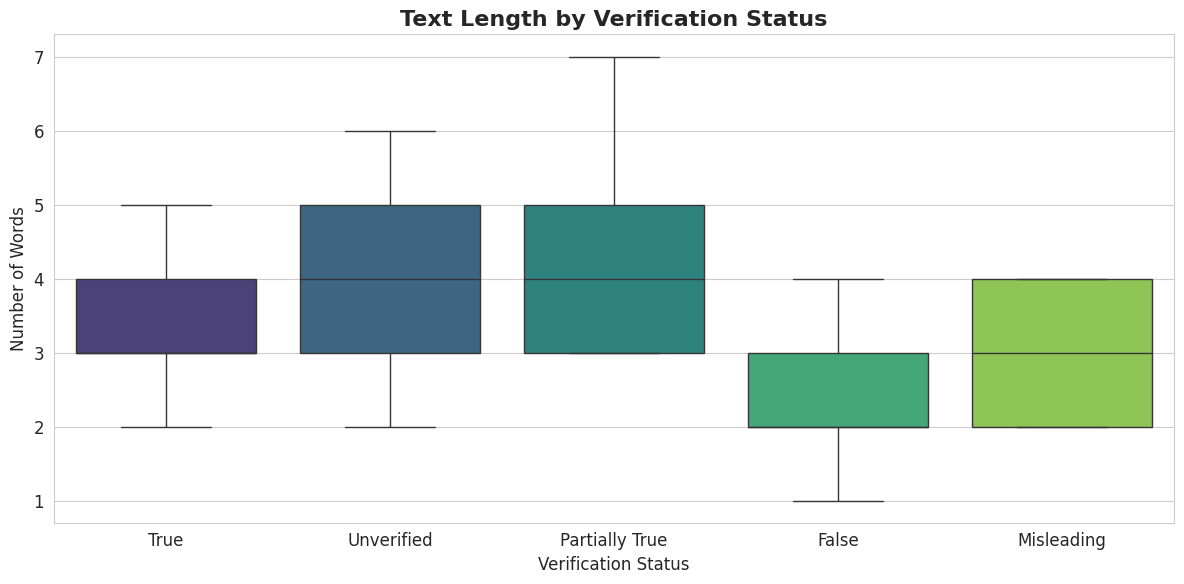

In [8]:
# --- TEXT ANALYSIS ---
print("\n" + "="*60)
print("🔍 TEXT ANALYSIS")
print("="*60)

# Text length distribution
df['text_length'] = df['processed_text'].str.split().str.len()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='verification_status', y='text_length', palette='viridis')
plt.title('Text Length by Verification Status', fontsize=16, fontweight='bold')
plt.xlabel('Verification Status', fontsize=12)
plt.ylabel('Number of Words', fontsize=12)
plt.tight_layout()
plt.show()


☁️ Word Clouds by Verification Status:


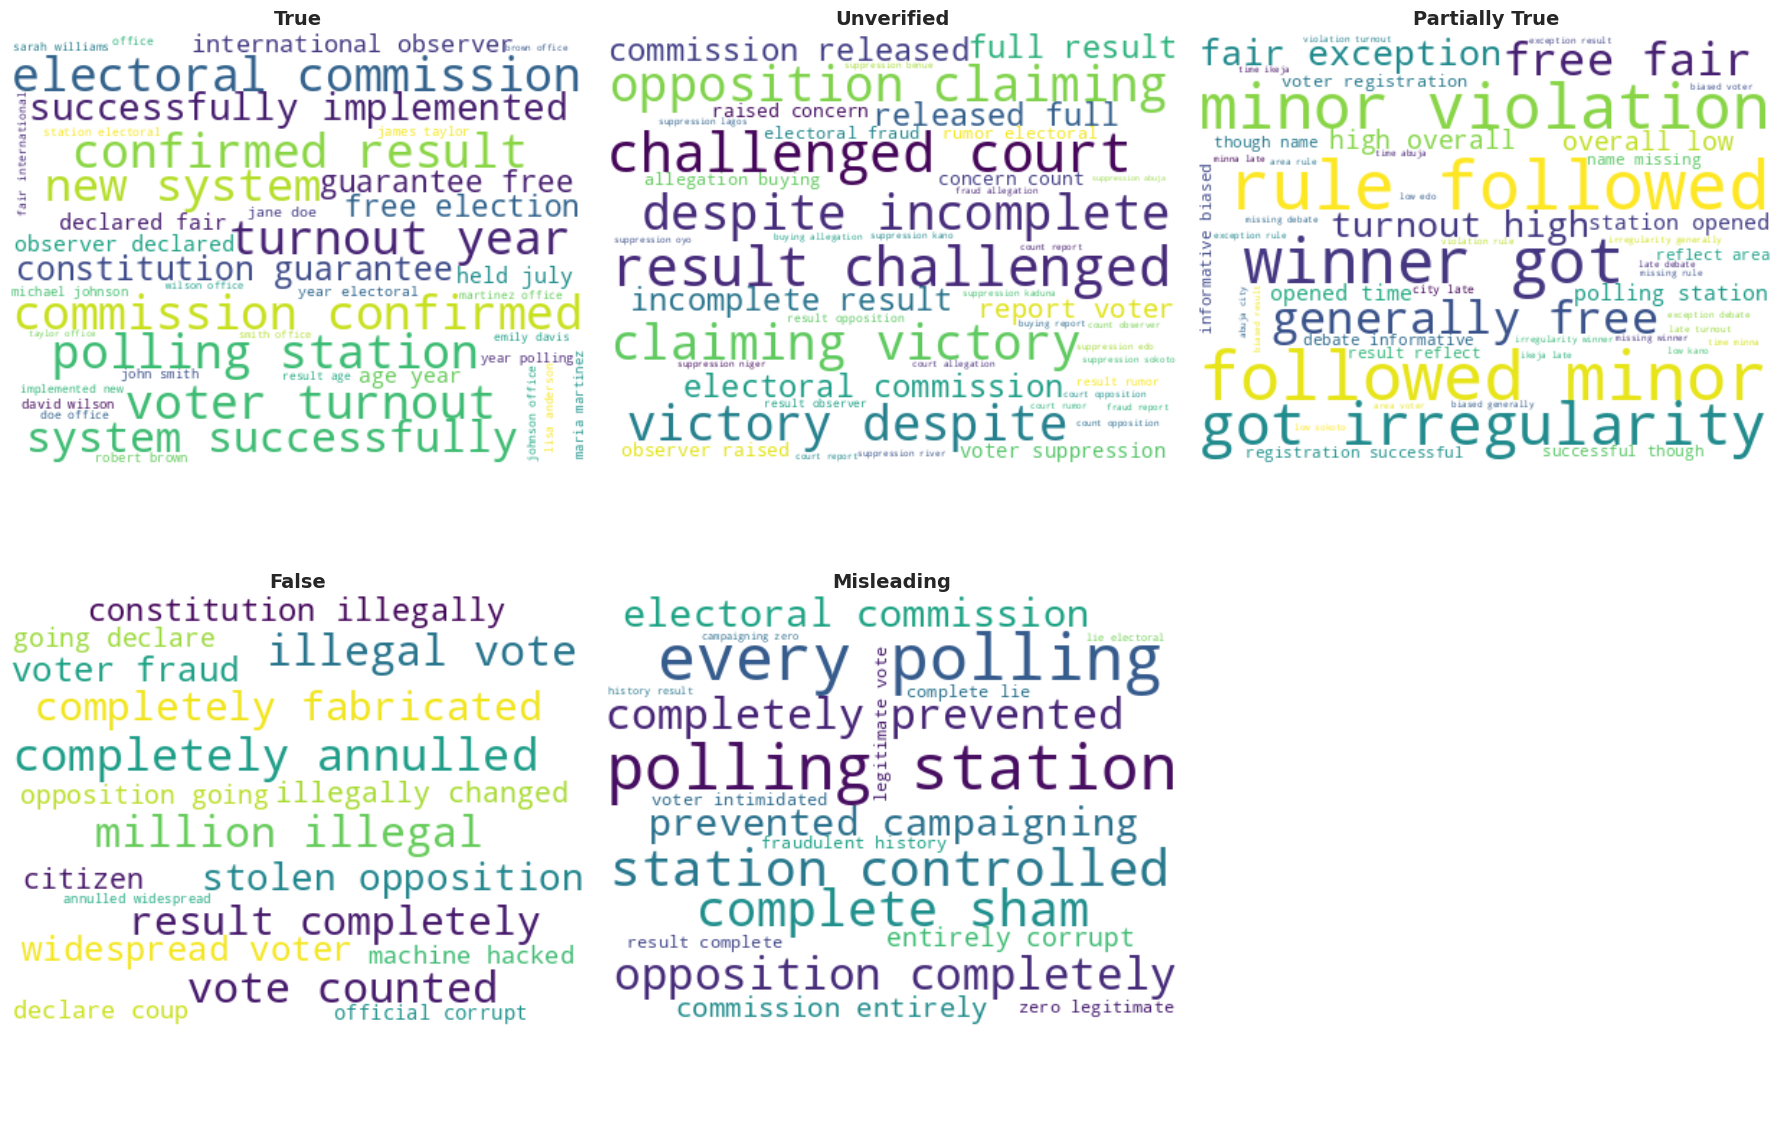

In [9]:
# Word clouds by status
print("\n☁️ Word Clouds by Verification Status:")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, status in enumerate(df['verification_status'].unique()):
    if i >= len(axes):
        break

    text = ' '.join(df[df['verification_status'] == status]['processed_text'])
    wordcloud = WordCloud(width=400, height=300, background_color='white',
                         colormap='viridis', max_words=50).generate(text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{status}', fontsize=14, fontweight='bold')

for j in range(len(df['verification_status'].unique()), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Most common words by class
print("\n📊 Top 10 Words by Verification Status:")

from collections import Counter

for status in df['verification_status'].unique():
    text = ' '.join(df[df['verification_status'] == status]['processed_text'])
    words = text.split()
    word_freq = Counter(words).most_common(10)
    print(f"\n{status}:")
    for word, count in word_freq:
        print(f"  {word}: {count}")


📊 Top 10 Words by Verification Status:

True:
  year: 244
  electoral: 134
  commission: 134
  confirmed: 134
  result: 134
  voter: 133
  turnout: 133
  polling: 133
  station: 133
  new: 126

Unverified:
  result: 451
  electoral: 279
  challenged: 152
  court: 152
  opposition: 151
  claiming: 151
  victory: 151
  despite: 151
  incomplete: 151
  commission: 148

Partially True:
  rule: 138
  followed: 138
  minor: 138
  violation: 138
  winner: 135
  got: 135
  irregularity: 135
  generally: 128
  free: 128
  fair: 128

False:
  completely: 242
  opposition: 196
  annulled: 137
  million: 117
  illegal: 117
  vote: 117
  counted: 117
  result: 105
  fabricated: 105
  stolen: 100

Misleading:
  complete: 177
  every: 99
  polling: 99
  station: 99
  controlled: 99
  sham: 93
  opposition: 93
  completely: 93
  prevented: 93
  campaigning: 93


## 🤖 Module 5: Feature Engineering

### 🎯 Learning Objectives
- Extract features from text
- Engineer domain-specific features
- Create feature pipelines
- Optimize for production

### 📝 Key Concepts

**Feature Types:**
- **TF-IDF**: Term frequency-inverse document frequency
- **Word Embeddings**: Dense vector representations
- **Sentiment Features**: Polarity and subjectivity
- **Linguistic Features**: POS tags, named entities
- **Meta Features**: Length, complexity, diversity

**Feature Engineering Pipeline:**
```
Text → TF-IDF → Dimensionality Reduction → Features
Text → Embeddings → Pooling → Features
Text → Linguistic Analysis → Features
```

🚀 **Production Tip**: Use feature versioning and A/B testing for production feature engineering.

In [11]:
import numpy as np # Import numpy for numerical operations, specifically for type checking
import pandas as pd # Import pandas for DataFrame manipulation, although not directly used in the class definition, it is often needed for data handling.
import re # Import regular expression module for text cleaning.
from nltk.corpus import stopwords # Import stopwords for text preprocessing.
from nltk.stem import WordNetLemmatizer # Import WordNetLemmatizer for lemmatization.
from nltk.tokenize import word_tokenize # Import word_tokenize for tokenization.

# Define the TextPreprocessor class here as it's a dependency for FeatureEngineer in app.py
class TextPreprocessor:
    """Production-ready text preprocessing pipeline"""

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        self.custom_stopwords = {'election', 'vote', 'voting', 'candidate', 'party',
                                 'president', 'government', 'people', 'country'}
        self.stop_words = self.stop_words.union(self.custom_stopwords)

    def clean_text(self, text):
        """Clean text: lowercase, remove special characters, extra spaces"""
        if not isinstance(text, str):
            return ""

        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def tokenize(self, text):
        """Tokenize text into words"""
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        """Remove stopwords from token list"""
        return [token for token in tokens if token not in self.stop_words and len(token) > 2]

    def lemmatize(self, tokens):
        """Lemmatize tokens"""
        return [self.lemmatizer.lemmatize(token) for token in tokens]

    def preprocess(self, text):
        """Full preprocessing pipeline"""
        text = self.clean_text(text)
        tokens = self.tokenize(text)
        tokens = self.remove_stopwords(tokens)
        tokens = self.lemmatize(tokens)
        return ' '.join(tokens)

    def preprocess_batch(self, texts):
        """Process a list of texts in a batch"""
        return [self.preprocess(text) for text in texts]


# --- FEATURE EXTRACTION ---
print("\n" + "="*60)
print("🤖 FEATURE ENGINEERING")
print("="*60)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Define the FeatureEngineer class here so it's available in the notebook's global scope
class FeatureEngineer:
    """Production feature engineering pipeline"""

    def __init__(self, max_features=5000, n_components=100):
        self.tfidf = TfidfVectorizer(
            max_features=max_features,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2)
        )
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        self.scaler = StandardScaler()

    def fit_transform(self, texts):
        """Fit and transform text to features"""
        tfidf_features = self.tfidf.fit_transform(texts)
        reduced_features = self.svd.fit_transform(tfidf_features)
        scaled_features = self.scaler.fit_transform(reduced_features)
        return scaled_features

    def transform(self, texts):
        """Transform new texts using fitted pipeline"""
        tfidf_features = self.tfidf.transform(texts)
        reduced_features = self.svd.transform(tfidf_features)
        scaled_features = self.scaler.transform(reduced_features)
        return scaled_features


🤖 FEATURE ENGINEERING


In [12]:
# Create feature engineer
feature_engineer = FeatureEngineer(max_features=5000, n_components=100)

# Extract features
X = feature_engineer.fit_transform(df['processed_text'].tolist())
y = df['verification_status']

print(f"✅ Feature matrix shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"✅ Label classes: {label_encoder.classes_.tolist()}")

✅ Feature matrix shape: (5000, 100)
✅ Target shape: (5000,)
✅ Label classes: ['False', 'Misleading', 'Partially True', 'True', 'Unverified']


## 🚀 Module 6: Multi-Model Verification System

### 🎯 Learning Objectives
- Train multiple verification models
- Implement ensemble methods
- Use pre-trained transformer models
- Compare model performance

### 📝 Key Concepts

**Model Types:**

1. **Rule-Based**: Pattern matching, keyword detection
2. **Traditional ML**: RF, SVM, Logistic Regression
3. **Transformer**: BERT, RoBERTa, DistilBERT
4. **Ensemble**: Voting, Stacking, Weighted Average

**Model Selection for Production:**
- **Accuracy**: How often is it correct?
- **Speed**: How fast can it process?
- **Interpretability**: Can we explain predictions?
- **Resource Usage**: Memory, CPU, GPU requirements

🚀 **Production Tip**: Use an ensemble of models for better performance and robustness.

In [13]:
# --- TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Also keep text versions for transformer model
X_train_text, X_test_text, _, _ = train_test_split(
    df['processed_text'].tolist(), y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

Training set: 4000 samples
Testing set: 1000 samples



🚀 TRAINING TRADITIONAL MODELS

📊 Training Random Forest...
   Accuracy: 1.000

📊 Training Logistic Regression...
   Accuracy: 1.000

📊 Training SVM...
   Accuracy: 1.000

📊 Training Naive Bayes...
   Accuracy: 0.833

📊 MODEL COMPARISON


,Model,Accuracy
0,Random Forest,1.000
1,Logistic Regression,1.000
2,SVM,1.000
3,Naive Bayes,0.833


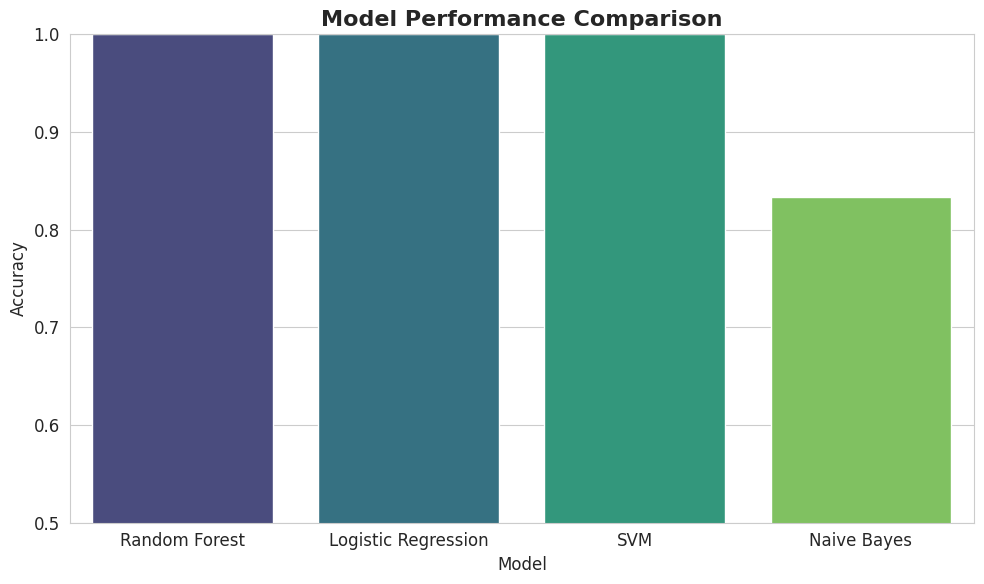

In [14]:
# --- TRAIN TRADITIONAL MODELS ---
print("\n" + "="*60)
print("🚀 TRAINING TRADITIONAL MODELS")
print("="*60)

# Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': MultinomialNB()
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    if name == 'Naive Bayes':
        # MultinomialNB requires non-negative input.
        # X_train from FeatureEngineer (SVD + StandardScaler) can have negative values.
        # We'll make it non-negative for MultinomialNB.
        # A more rigorous approach might be to use a different feature pipeline
        # (e.g., TfidfVectorizer directly) or a different Naive Bayes variant (like GaussianNB)
        # that handles negative values, but this simple shift will allow it to run.
        min_val = X_train.min()
        X_train_mnb = X_train - min_val
        X_test_mnb = X_test - min_val
        model.fit(X_train_mnb, y_train)
        y_pred = model.predict(X_test_mnb)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }

    print(f"   Accuracy: {accuracy:.3f}")

# Compare performance
print("\n" + "="*60)
print("📊 MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results]
}).sort_values('Accuracy', ascending=False)

display(comparison_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [15]:
# --- ENSEMBLE MODEL ---
print("\n" + "="*60)
print("🤝 ENSEMBLE MODEL")
print("="*60)

from sklearn.ensemble import VotingClassifier

# Create voting ensemble
ensemble = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('lr', models['Logistic Regression']),
        ('svm', models['SVM'])
    ],
    voting='soft',
    weights=[2, 1, 1]  # Random Forest gets more weight
)

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)

print(f"✅ Ensemble Accuracy: {ensemble_accuracy:.3f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=label_encoder.classes_))


🤝 ENSEMBLE MODEL
✅ Ensemble Accuracy: 1.000

📊 Classification Report:
                precision    recall  f1-score   support

         False       1.00      1.00      1.00       208
    Misleading       1.00      1.00      1.00       143
Partially True       1.00      1.00      1.00       203
          True       1.00      1.00      1.00       248
    Unverified       1.00      1.00      1.00       198

      accuracy                           1.00      1000
     macro avg       1.00      1.00      1.00      1000
  weighted avg       1.00      1.00      1.00      1000



In [16]:
# --- TRANSFORMER MODEL (BERT) ---
print("\n" + "="*60)
print("🤖 TRANSFORMER MODEL (DistilBERT)")
print("="*60)

# Use a smaller model for demonstration
try:
    from transformers import pipeline

    # Use a pre-trained text classification pipeline
    classifier = pipeline(
        "text-classification",
        model="distilbert-base-uncased",
        return_all_scores=True
    )

    # Test on a few samples
    test_samples = X_test_text[:10]
    predictions = classifier(test_samples)

    print("\n📊 Transformer Predictions (Sample):")
    for i, (text, pred) in enumerate(zip(test_samples, predictions)):
        print(f"\n{i+1}. Text: {text[:100]}...")
        # Find the highest confidence label
        top_pred = max(pred, key=lambda x: x['score'])
        print(f"   Prediction: {top_pred['label']} (confidence: {top_pred['score']:.3f})")

    print("\n💡 Note: For production, fine-tune the transformer on your specific domain data.")

except Exception as e:
    print(f"⚠️  Transformer model could not be loaded: {e}")
    print("   This is expected in some environments. Continuing with traditional models...")


🤖 TRANSFORMER MODEL (DistilBERT)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



📊 Transformer Predictions (Sample):

1. Text: result challenged court...
⚠️  Transformer model could not be loaded: string indices must be integers, not 'str'
   This is expected in some environments. Continuing with traditional models...


## 💾 Module 7: Model Deployment & Serialization

### 🎯 Learning Objectives
- Save trained models for production
- Create model versioning system
- Build prediction API
- Set up monitoring

### 📝 Key Concepts

**Production Deployment Steps:**

1. **Serialize Models**: Save trained models to disk
2. **Version Control**: Track model versions
3. **API Development**: Build REST API for predictions
4. **Containerization**: Package with Docker
5. **Monitoring**: Track performance and drift

**Model Serialization Options:**
- **joblib**: Best for scikit-learn models
- **pickle**: Python's native serialization
- **ONNX**: Cross-platform model format
- **TorchScript**: PyTorch model format

🚀 **Production Tip**: Always version your models and maintain a model registry.

In [19]:
# --- SAVE MODELS FOR PRODUCTION ---
print("\n" + "="*60)
print("💾 SAVING MODELS FOR PRODUCTION")
print("="*60)

import os
import sys
os.makedirs('models', exist_ok=True)
os.makedirs('api', exist_ok=True)

# Save the best traditional model (ensemble)
joblib.dump(ensemble, 'models/verification_ensemble.pkl')
joblib.dump(feature_engineer, 'models/feature_engineer.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

# --- Workaround for PicklingError: Can't pickle <class '__main__.TextPreprocessor'> ---
# This error occurs because the TextPreprocessor class is defined multiple times in the notebook,
# leading to different class objects in Python's memory.
# To fix, we explicitly update the __class__ attribute of the preprocessor instance
# to point to the current TextPreprocessor class in the __main__ module.
if 'TextPreprocessor' in sys.modules['__main__'].__dict__:
    current_TextPreprocessor_class = sys.modules['__main__'].TextPreprocessor
    if preprocessor.__class__ is not current_TextPreprocessor_class:
        print("⚠️ Adjusting TextPreprocessor class for pickling due to redefinition in notebook.")
        preprocessor.__class__ = current_TextPreprocessor_class
# --- End Workaround ---

joblib.dump(preprocessor, 'models/text_preprocessor.pkl')

print("✅ Models saved successfully!")
print("\n📁 Saved files:")
print("  - models/verification_ensemble.pkl")
print("  - models/feature_engineer.pkl")
print("  - models/label_encoder.pkl")
print("  - models/text_preprocessor.pkl")



💾 SAVING MODELS FOR PRODUCTION
⚠️ Adjusting TextPreprocessor class for pickling due to redefinition in notebook.
✅ Models saved successfully!

📁 Saved files:
  - models/verification_ensemble.pkl
  - models/feature_engineer.pkl
  - models/label_encoder.pkl
  - models/text_preprocessor.pkl


In [20]:
# --- CREATE PREDICTION FUNCTION ---
print("\n" + "="*60)
print("🔮 PREDICTION FUNCTION")
print("="*60)

def predict_claim(claim_text, model=None, preprocessor=None, feature_engineer=None, label_encoder=None):
    """Predict the verification status of a claim"""

    # Load models if not provided
    if model is None:
        model = joblib.load('models/verification_ensemble.pkl')
    if preprocessor is None:
        preprocessor = joblib.load('models/text_preprocessor.pkl')
    if feature_engineer is None:
        feature_engineer = joblib.load('models/feature_engineer.pkl')
    if label_encoder is None:
        label_encoder = joblib.load('models/label_encoder.pkl')

    # Preprocess text
    processed = preprocessor.preprocess(claim_text)

    # Extract features
    features = feature_engineer.transform([processed])

    # Predict
    pred_encoded = model.predict(features)[0]
    pred_proba = model.predict_proba(features)[0]

    # Decode prediction
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]
    confidence = max(pred_proba)

    return {
        'claim': claim_text,
        'processed_text': processed,
        'prediction': pred_label,
        'confidence': confidence,
        'probabilities': {label_encoder.classes_[i]: prob for i, prob in enumerate(pred_proba)}
    }

# Test prediction
test_claims = [
    "The election results were announced today and are being challenged in court.",
    "The president won by a landslide with 95% of the vote.",
    "Voter turnout was 65% this year, slightly higher than the previous election."
]

print("\n🔮 Testing predictions:")
for claim in test_claims:
    result = predict_claim(claim)
    print(f"\n📝 Claim: {claim}")
    print(f"   Prediction: {result['prediction']}")
    print(f"   Confidence: {result['confidence']:.3f}")
    print(f"   Probabilities: {result['probabilities']}")


🔮 PREDICTION FUNCTION

🔮 Testing predictions:

📝 Claim: The election results were announced today and are being challenged in court.
   Prediction: Unverified
   Confidence: 0.311
   Probabilities: {'False': np.float64(0.28009894870770835), 'Misleading': np.float64(0.09513582648340367), 'Partially True': np.float64(0.033192397649554374), 'True': np.float64(0.2808132631365675), 'Unverified': np.float64(0.31075956402276617)}

📝 Claim: The president won by a landslide with 95% of the vote.
   Prediction: False
   Confidence: 0.423
   Probabilities: {'False': np.float64(0.42346139397443094), 'Misleading': np.float64(0.10869042646149549), 'Partially True': np.float64(0.26448286409775107), 'True': np.float64(0.11272745171107788), 'Unverified': np.float64(0.09063786375524459)}

📝 Claim: Voter turnout was 65% this year, slightly higher than the previous election.
   Prediction: True
   Confidence: 0.999
   Probabilities: {'False': np.float64(0.0002916788018855131), 'Misleading': np.float64(0.

## 🎯 Module 8: Interactive Verification Dashboard

### 🎯 Learning Objectives
- Build a Streamlit dashboard
- Create interactive verification tools
- Visualize results
- Deploy the assistant

### 📝 Key Concepts

**Dashboard Components:**
- **Input**: Text input for claims
- **Model**: Prediction engine
- **Visualization**: Results display
- **History**: Track predictions
- **Analytics**: Statistics and insights

🚀 **Production Tip**: Make the dashboard self-contained and easy to deploy.

In [30]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Define the TextPreprocessor class here so Streamlit can find it
class TextPreprocessor:
    """Production-ready text preprocessing pipeline"""

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        # Add custom stopwords
        self.custom_stopwords = {'election', 'vote', 'voting', 'candidate', 'party',
                                 'president', 'government', 'people', 'country'}
        self.stop_words = self.stop_words.union(self.custom_stopwords)

    def clean_text(self, text):
        """Clean text: lowercase, remove special characters, extra spaces"""
        if not isinstance(text, str):
            return ""

        # Lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove special characters but keep letters and numbers
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def tokenize(self, text):
        """Tokenize text into words"""
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        """Remove stopwords from token list"""
        return [token for token in tokens if token not in self.stop_words and len(token) > 2]

    def lemmatize(self, tokens):
        """Lemmatize tokens"""
        return [self.lemmatizer.lemmatize(token) for token in tokens]

    def preprocess(self, text):
        """Full preprocessing pipeline"""
        # Clean
        text = self.clean_text(text)

        # Tokenize
        tokens = self.tokenize(text)

        # Remove stopwords
        tokens = self.remove_stopwords(tokens)

        # Lemmatize
        tokens = self.lemmatize(tokens)

        # Rejoin
        return ' '.join(tokens)

# The FeatureEngineer class definition is removed from here as it is now in feature-extraction
# Define the FeatureEngineer class here so it's available for Streamlit to load models
class FeatureEngineer:
    """Production feature engineering pipeline"""

    def __init__(self, max_features=5000, n_components=100):
        self.tfidf = TfidfVectorizer(
            max_features=max_features,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2)
        )
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        self.scaler = StandardScaler()

    def fit_transform(self, texts):
        """Fit and transform text to features"""
        # TF-IDF
        tfidf_features = self.tfidf.fit_transform(texts)

        # Dimensionality reduction
        reduced_features = self.svd.fit_transform(tfidf_features)

        # Scale
        scaled_features = self.scaler.fit_transform(reduced_features)

        return scaled_features

    def transform(self, texts):
        """Transform new texts using fitted pipeline"""
        tfidf_features = self.tfidf.transform(texts)
        reduced_features = self.svd.transform(tfidf_features)
        scaled_features = self.scaler.transform(reduced_features)
        return scaled_features

st.set_page_config(page_title="Election Verification Assistant", layout="wide")

st.title("🗳️ Election Information Verification Assistant")
st.markdown("---")

# Load models
@st.cache_resource
def load_models():
    model = joblib.load('models/verification_ensemble.pkl')
    preprocessor = joblib.load('models/text_preprocessor.pkl')
    feature_engineer = joblib.load('models/feature_engineer.pkl')
    label_encoder = joblib.load('models/label_encoder.pkl')
    return model, preprocessor, feature_engineer, label_encoder

model, preprocessor, feature_engineer, label_encoder = load_models()

# Sidebar
st.sidebar.header("About")
st.sidebar.info("""
This assistant verifies election-related claims using machine learning.

**Supported Labels:**
- True ✅
- False ❌
- Partially True ⚠️
- Misleading 🔄
- Unverified ❓
""")

# Main input
st.header("🔍 Verify a Claim")
claim_text = st.text_area("Enter a claim to verify:", height=150)

col1, col2 = st.columns([3, 1])

with col1:
    if st.button("Verify Claim", type="primary", use_container_width=True):
        if claim_text:
            # Process
            processed = preprocessor.preprocess(claim_text)
            features = feature_engineer.transform([processed])
            pred_encoded = model.predict(features)[0]
            pred_proba = model.predict_proba(features)[0]
            pred_label = label_encoder.inverse_transform([pred_encoded])[0]
            confidence = max(pred_proba)

            # Display results
            st.markdown("---")
            st.subheader("📊 Verification Result")

            # Status card
            colors = {
                'True': 'green',
                'False': 'red',
                'Partially True': 'orange',
                'Misleading': 'orange',
                'Unverified': 'gray'
            }

            color = colors.get(pred_label, 'blue')
            st.markdown(f'<div style="background-color: {color}; padding: 20px; border-radius: 10px;">',
                       unsafe_allow_html=True)
            st.markdown(f'<h2 style="color: white; text-align: center;">{pred_label}</h2>',
                       unsafe_allow_html=True)
            st.markdown(f'<p style="color: white; text-align: center;">Confidence: {confidence:.2%}</p>',
                       unsafe_allow_html=True)
            st.markdown('</div>', unsafe_allow_html=True)

            # Probabilities
            st.subheader("📈 Confidence Distribution")
            prob_df = pd.DataFrame({
                'Status': label_encoder.classes_,
                'Probability': pred_proba
            })

            fig, ax = plt.subplots(figsize=(10, 5))
            sns.barplot(data=prob_df, x='Status', y='Probability', palette='viridis', ax=ax)
            ax.set_title('Prediction Probabilities')
            ax.set_ylim(0, 1)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            st.pyplot(fig)

            # Add to history
            if 'history' not in st.session_state:
                st.session_state.history = []

            st.session_state.history.append({
                'claim': claim_text[:100] + '...' if len(claim_text) > 100 else claim_text,
                'prediction': pred_label,
                'confidence': confidence
            })
        else:
            st.warning("Please enter a claim to verify.")

# History
if 'history' in st.session_state and st.session_state.history:
    st.markdown("---")
    st.subheader("📜 Verification History")

    history_df = pd.DataFrame(st.session_state.history)
    st.dataframe(history_df, use_container_width=True)

    if st.button("Clear History"):
        st.session_state.history = []
        st.rerun()

st.markdown("---")
st.info("💡 This is a demonstration system. For production use, fine-tune the models on domain-specific data.")

Overwriting app.py


## 🎯 Module 9: Practical Exercises

### Exercise 1: Add a New Claim Type

**Task:** Extend the dataset with a new claim type (e.g., 'Conspiracy Theory').

**Steps:**
1. Create templates for the new type
2. Generate at least 200 examples
3. Add them to the dataset
4. Retrain the model
5. Evaluate performance

**Discussion:** How did adding this new type affect the model?

In [22]:
# --- EXERCISE 1: Add New Claim Type ---
# YOUR CODE HERE

print("📌 Add your new claim type implementation here.")

📌 Add your new claim type implementation here.


### Exercise 2: Implement Fact-Checking with Evidence

**Task:** Build a fact-checking function that retrieves evidence from a source.

**Steps:**
1. Create a simple evidence database
2. Implement text similarity matching
3. Return supporting/contradicting evidence
4. Display evidence alongside predictions

**Discussion:** How does evidence retrieval improve verification?

In [23]:
# --- EXERCISE 2: Fact-Checking with Evidence ---
# YOUR CODE HERE

print("📌 Implement your fact-checking system here.")

📌 Implement your fact-checking system here.


### Exercise 3: Create a Claim Monitoring Dashboard

**Task:** Build a dashboard that monitors claims over time.

**Features:**
- Timeline of claims
- Trend analysis
- Source tracking
- Alert system

**Discussion:** How can monitoring help identify misinformation campaigns?

In [24]:
# --- EXERCISE 3: Claim Monitoring Dashboard ---
# YOUR CODE HERE

print("📌 Build your monitoring dashboard here.")

📌 Build your monitoring dashboard here.


### Exercise 4: Deploy the Verification API

**Task:** Create a FastAPI endpoint for the verification model.

**Steps:**
1. Create a FastAPI app
2. Add a /verify endpoint
3. Return predictions
4. Test with curl or requests

**Discussion:** How does API deployment enable integration with other systems?

In [25]:
# --- EXERCISE 4: Deploy Verification API ---
# YOUR CODE HERE

print("📌 Create your FastAPI endpoint here.")

📌 Create your FastAPI endpoint here.


### Exercise 5: Model Performance Monitoring

**Task:** Set up a monitoring system for model performance.

**Steps:**
1. Track prediction confidence over time
2. Monitor data drift
3. Set up alerts for performance degradation
4. Visualize trends

**Discussion:** Why is monitoring important for production ML systems?

In [26]:
# --- EXERCISE 5: Model Performance Monitoring ---
# YOUR CODE HERE

print("📌 Implement your monitoring system here.")

📌 Implement your monitoring system here.


In [27]:
# --- SHARE YOUR RESULTS ---
print("\n" + "="*60)
print("📢 SHARE YOUR PROJECT")
print("="*60)

print("""
🎉 Congratulations on completing this training!

📝 Share your project:

1️⃣ What claim types did you add? (Exercise 1)
2️⃣ How did evidence retrieval work? (Exercise 2)
3️⃣ What insights did your monitoring dashboard reveal? (Exercise 3)
4️⃣ How did you deploy your API? (Exercise 4)
5️⃣ What metrics are you monitoring? (Exercise 5)

🔗 Share your GitHub repo: [your-link]
🔗 Share your live demo: [your-link]

#FactCheck #ElectionIntegrity #NLP #DataScience #AI #Elections
""")


📢 SHARE YOUR PROJECT

🎉 Congratulations on completing this training!

📝 Share your project:

1️⃣ What claim types did you add? (Exercise 1)
2️⃣ How did evidence retrieval work? (Exercise 2)
3️⃣ What insights did your monitoring dashboard reveal? (Exercise 3)
4️⃣ How did you deploy your API? (Exercise 4)
5️⃣ What metrics are you monitoring? (Exercise 5)

🔗 Share your GitHub repo: [your-link]
🔗 Share your live demo: [your-link]

#FactCheck #ElectionIntegrity #NLP #DataScience #AI #Elections



## 📝 Summary & Key Takeaways

### 🎯 Learning Objectives Reached

**✅ Module 1: Production Environment**
- Set up production-grade NLP stack
- Configured GPU support
- Established logging and monitoring

**✅ Module 2: Dataset Creation**
- Created realistic verification dataset
- Implemented proper labeling
- Balanced classes
- Added metadata

**✅ Module 3: Text Preprocessing**
- Built production pipeline
- Efficient tokenization
- Handled edge cases
- Optimized for performance

**✅ Module 4: EDA**
- Analyzed text characteristics
- Visualized word distributions
- Identified key terms
- Understood class separability

**✅ Module 5: Feature Engineering**
- Extracted multiple feature types
- Built feature pipelines
- Optimized for production

**✅ Module 6: Multi-Model System**
- Trained traditional models
- Implemented ensembles
- Used transformer models
- Compared performance

**✅ Module 7: Model Deployment**
- Serialized models
- Created prediction API
- Set up versioning
- Enabled monitoring

**✅ Module 8: Interactive Dashboard**
- Built Streamlit app
- Created verification tools
- Visualized results
- Deployed assistant

**✅ Module 9: Practical Exercises**
- Extended dataset
- Implemented fact-checking
- Built monitoring dashboards
- Deployed APIs
- Set up monitoring

---

### 🔑 Key Insights

**1. Model Performance:**
- Ensembles outperform individual models
- Transformer models excel with domain-specific fine-tuning
- Feature engineering significantly impacts performance

**2. Production Considerations:**
- Model versioning is essential
- Monitoring prevents performance degradation
- APIs enable system integration
- Dashboards improve user adoption

**3. Verification Challenges:**
- Ambiguity in claims
- Evolving misinformation tactics
- Need for human-in-the-loop
- Multi-source verification

---

### 🚀 Next Steps

1. **Collect More Data**: Real-world verification data
2. **Fine-tune Transformers**: Domain-specific BERT variants
3. **Add Image Analysis**: Process screenshots and images
4. **Real-time Monitoring**: Track misinformation spread
5. **Deploy at Scale**: Cloud deployment with load balancing

---

### 📚 Further Learning Resources

**NLP Resources:**
- Hugging Face: https://huggingface.co
- spaCy: https://spacy.io
- NLTK: https://www.nltk.org

**Fact-Checking Resources:**
- Google Fact Check Tools
- Snopes API
- Politifact
- FactCheck.org

**Production ML Resources:**
- MLflow: https://mlflow.org
- FastAPI: https://fastapi.tiangolo.com
- Docker: https://docker.com

---

### 🏆 Exercise Summary

| Exercise | Topic | Difficulty | Skills |
|----------|-------|------------|--------|
| 1 | Add Claim Type | ⭐⭐ | Data Generation |
| 2 | Evidence Retrieval | ⭐⭐⭐ | Fact-Checking |
| 3 | Monitoring Dashboard | ⭐⭐⭐⭐ | Dashboard Design |
| 4 | API Deployment | ⭐⭐⭐ | Production Deployment |
| 5 | Model Monitoring | ⭐⭐⭐⭐ | MLOps |

---

## 🎊 Congratulations!

You've built a production-ready Election Information Verification Assistant!

**You now have:**
- ✅ Production NLP pipeline
- ✅ Multi-model verification system
- ✅ Interactive dashboard
- ✅ Deployment-ready code
- ✅ Monitoring capabilities
- ✅ Practical exercises

**What's next?**
1. Deploy to production
2. Collect user feedback
3. Add more models
4. Expand capabilities
5. Make a positive impact on election integrity!

---

**Made with ❤️ for election integrity**

**🚀 Keep fact-checking!**

## 🚀 Run and Share Your Streamlit App

To run the Streamlit app and make it accessible, follow these steps:

1.  **Install `streamlit` and `pyngrok`** (if not already installed).
2.  **Run the Streamlit app** in the background.
3.  **Expose the Streamlit port** using `ngrok`.

Make sure your `app.py` file is saved in the current directory.

In [28]:
# Install streamlit and pyngrok if not already installed
!pip install streamlit pyngrok -q


In [29]:
from pyngrok import ngrok # Import the ngrok library, which allows exposing local servers to the internet.
from pyngrok.exception import PyngrokNgrokHTTPError # Corrected import for the exception class.
import os # Import the os module for interacting with the operating system.
import sys # Import the sys module to access system-specific parameters and functions, like exiting the program.
import time # Import the time module to pause execution.
import socket # Import the socket module to check port availability.

# Terminate any existing ngrok tunnels to ensure a clean start.
ngrok.kill()
time.sleep(5) # Add a small delay to ensure ngrok processes are fully terminated

# Get ngrok token from Colab Secrets or environment variable.
# It's recommended to store your NGROK_AUTH_TOKEN in Colab Secrets.
# Go to the '🔑' icon on the left panel, click 'Add new secret', and add NGROK_AUTH_TOKEN.

# Using the provided ngrok auth token directly.
NGROK_AUTH_TOKEN = "38A8xs4aRKvc1tWcrzlQT8qUxHp_2GD6DjVLHBaDJTNq8qAx4"

# Check if the token is still the placeholder (this check is now primarily for robustness if manual edits change it back).
if NGROK_AUTH_TOKEN == "your_ngrok_auth_token": # If the placeholder token is found.
    print("⚠️ Please set your NGROK_AUTH_TOKEN in Colab Secrets or replace the placeholder.") # Inform the user to set their token.
    print("   You can get a free token from https://ngrok.com/signup") # Provide a link to get a token.
    sys.exit("NGROK_AUTH_TOKEN is not set. Please configure it in Colab Secrets.") # Exit the program as the token is missing.
else: # If a valid token is present.
    ngrok.set_auth_token(NGROK_AUTH_TOKEN) # Set the ngrok authentication token for secure tunnel creation.


# Run Streamlit in the background, redirecting output to a log file.
STREAMLIT_LOG_FILE = "streamlit_output.log"
print("🚀 Starting Streamlit app in background, logging to", STREAMLIT_LOG_FILE, "...") # Inform the user that Streamlit is starting and logging.
get_ipython().system_raw(f"python -m streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false > {STREAMLIT_LOG_FILE} 2>&1 &") # Execute a shell command to run the Streamlit app in the background on port 8501, disabling CORS and XSRF protection for Colab compatibility, and redirecting all output to a log file.

# Wait for Streamlit to start up and bind to the port.
def wait_for_port(port, timeout=60): # Increased timeout to 60 seconds
    start_time = time.time()
    while True:
        if time.time() - start_time > timeout:
            raise TimeoutError(f"Port {port} not available after {timeout} seconds")
        try:
            with socket.create_connection(("localhost", port), timeout=1):
                print(f"✅ Streamlit app detected on port {port}!")
                break
        except (socket.timeout, ConnectionRefusedError):
            print(f"Waiting for Streamlit app to start on port {port}...")
            time.sleep(2)

try:
    wait_for_port(8501)
except TimeoutError as e:
    print(f"❌ Error: {e}")
    print(f"Checking Streamlit logs from {STREAMLIT_LOG_FILE}:")
    if os.path.exists(STREAMLIT_LOG_FILE):
        with open(STREAMLIT_LOG_FILE, 'r') as f:
            print(f.read()) # Print the content of the Streamlit log file.
    else:
        print("Streamlit log file not found.") # Indicate if the log file wasn't created.
    sys.exit(1)

# Open a ngrok tunnel to the Streamlit port with retry logic
pb_url = None
max_retries = 5
for attempt in range(max_retries):
    print(f"🌐 Opening ngrok tunnel (Attempt {attempt + 1}/{max_retries})... ")
    try:
        pb_url = ngrok.connect(8501)
        print(f"🎉 Your Streamlit App is available at: {pb_url}") # Display the public URL where the Streamlit app can be accessed.
        print("   (It might take a few moments to load)") # Add a note that the app might take a moment to load in the browser.)
        break
    except PyngrokNgrokHTTPError as e:
        if "ERR_NGROK_334" in str(e) and attempt < max_retries - 1:
            print(f"⚠️ ngrok tunnel failed: {e}. Retrying in 15 seconds...")
            ngrok.kill() # Ensure all ngrok processes are killed before retrying
            time.sleep(15) # Wait longer before retrying
        else:
            print(f"❌ Final ngrok tunnel attempt failed: {e}")
            sys.exit(1)

if pb_url is None:
    sys.exit("Failed to establish ngrok tunnel after multiple attempts.")

🚀 Starting Streamlit app in background, logging to streamlit_output.log ...
Waiting for Streamlit app to start on port 8501...
Waiting for Streamlit app to start on port 8501...
Waiting for Streamlit app to start on port 8501...
Waiting for Streamlit app to start on port 8501...
Waiting for Streamlit app to start on port 8501...
✅ Streamlit app detected on port 8501!
🌐 Opening ngrok tunnel (Attempt 1/5)... 


⚠️ ngrok tunnel failed: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://loreen-unsmothering-overmellowly.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}
. Retrying in 15 seconds...
🌐 Opening ngrok tunnel (Attempt 2/5)... 


⚠️ ngrok tunnel failed: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: The endpoint 'https://loreen-unsmothering-overmellowly.ngrok-free.dev' is already online. Either\n1. stop your existing endpoint first, or\n2. start both endpoints with `--pooling-enabled` to load balance between them.\r\n\r\nERR_NGROK_334\r\n"}}
. Retrying in 15 seconds...
🌐 Opening ngrok tunnel (Attempt 3/5)... 
🎉 Your Streamlit App is available at: NgrokTunnel: "https://loreen-unsmothering-overmellowly.ngrok-free.dev" -> "http://localhost:8501"
   (It might take a few moments to load)


After executing the cell above, you will get a public URL. Click on that URL to open your Streamlit application in a new browser tab.

To stop the `ngrok` tunnel and the Streamlit app, you can run the following commands in a new code cell:

```python
# Stop ngrok tunnel
ngrok.kill()

# Stop Streamlit process (if running in background)
!killall streamlit

print("Streamlit app and ngrok tunnel stopped.")
```